# Naloga 5 - Konvolucijske nevronske mreze (CNN)

Razvrscanje slik zbirke **shapes** v 3 razrede: `circles`, `squares`, `triangles`.

Postopek:
1. Gradnja `DataFrame` s stolpcema `filepath` in `label`.
2. Priprava `ImageDataGenerator` (normalizacija + validacijska razdelitev).
3. **5-kratno precno preverjanje** z `flow_from_dataframe` iteratorji.
4. Dva modela CNN (predpisana arhitektura + lastna arhitektura), ucenje do 50 epoh.
5. Ovrednotenje (tocnost, utezeni F1, preciznost, priklic) + boxploti in stolpicni diagrami.

In [1]:
# Uvoz knjiznic in nastavitev semen
import numpy as np, pandas as pd, glob, os, pickle
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score)
import warnings; warnings.filterwarnings('ignore')
np.random.seed(1234); tf.random.set_seed(1234)
print('TensorFlow', tf.__version__)

TensorFlow 2.18.1


## Obdelava podatkov - gradnja DataFrame (filepath, label)

In [2]:
# Gradnja DataFrame z dvema stolpcema: filepath in label
RAZREDI = ['circles','squares','triangles']
vrstice = []
for label in RAZREDI:
    for fp in glob.glob(f'shapes/{label}/*.png'):
        vrstice.append({'filepath': fp, 'label': label})
df = pd.DataFrame(vrstice).sample(frac=1, random_state=1234).reset_index(drop=True)
print('Oblika DataFrame:', df.shape)
print(df['label'].value_counts())
df.head()

Oblika DataFrame: (300, 2)
label
squares      100
triangles    100
circles      100
Name: count, dtype: int64


,filepath,label
0,shapes/squares\drawing(67).png,squares
1,shapes/triangles\drawing(1).png,triangles
2,shapes/circles\drawing(75).png,circles
3,shapes/squares\drawing(66).png,squares
4,shapes/squares\drawing(22).png,squares


## Priprava ImageDataGenerator objektov

- **Ucni** generator: `rescale=1/255` (normalizacija) + `validation_split=0.2` (razmerje 80:20).
- **Testni** generator: `rescale=1/255`.

In [3]:
# Generatorji slik:
#  - train_datagen: osnovni (rescale + validation_split=0.2) -> uporablja Model 1 (predpisana arhitektura)
#  - train_datagen_aug: dodatno AUGMENTIRA (rotacija, zamik, povecava) -> Model 2 in finalni model,
#    kar mocno izboljsa generalizacijo pri majhni mnozici rocno risanih oblik
#  - test_datagen: samo normalizacija
IMG_SIZE = (100, 100)   # vhodne slike 100 x 100
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_datagen_aug = ImageDataGenerator(rescale=1./255, validation_split=0.2,
                                       rotation_range=20, width_shift_range=0.1,
                                       height_shift_range=0.1, zoom_range=0.15)
test_datagen  = ImageDataGenerator(rescale=1./255)

## Definicija dveh arhitektur CNN

**Model 1 (predpisana arhitektura):** Conv(16) -> MaxPool -> Conv(16) -> MaxPool ->
Flatten -> Dense(128, relu) -> Dense(3, softmax).

**Model 2 (lastna arhitektura):** globlja mreza z vec filtri, BatchNorm in Dropout,
ter spremenjenimi hiperparametri ucenja (manjsi paketi, prilagojena ucna stopnja).

In [4]:
# Model 1 - predpisana arhitektura iz navodil
def build_model1():
    model = Sequential([
        Input(shape=(100,100,1)),                       # vhod 100x100x1 (sivinska slika)
        Conv2D(16, (3,3), activation='relu'),           # konvolucijski sloj 16 filtrov 3x3
        MaxPooling2D(),                                  # maksimizacijski zdruzevalni sloj
        Conv2D(16, (3,3), activation='relu'),           # 2. konvolucijski sloj 16 filtrov 3x3
        MaxPooling2D(),                                  # 2. zdruzevalni sloj
        Flatten(),                                       # splostitev v vektor
        Dense(128, activation='relu'),                   # polno povezan sloj 128 nevronov
        Dense(3, activation='softmax')                   # izhod 3 razredi (softmax)
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model 2 - lastna (izboljsana) arhitektura + drugacni hiperparametri
def build_model2():
    model = Sequential([
        Input(shape=(100,100,1)),
        Conv2D(32, (3,3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu', padding='same'), MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    # spremenjeni hiperparametri: prilagojena ucna stopnja (adam, lr=0.0005)
    model.compile(optimizer=Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## 5-kratno precno preverjanje, ucenje in ovrednotenje

V vsakem prečnem rezu ustvarimo ucni, validacijski in testni iterator z `flow_from_dataframe`
ter naucimo oba modela do 50 epoh.

In [5]:
# Pomozna funkcija: ustvari iteratorje za en precni rez in nauci podan model
EPOCHS = 50
def iteratorji(train_df, test_df, batch_size, datagen=None):
    datagen = datagen or train_datagen   # privzeto osnovni generator (Model 1)
    train_it = datagen.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        color_mode='grayscale', class_mode='categorical', classes=RAZREDI,
        batch_size=batch_size, subset='training', shuffle=True, seed=1234)
    val_it = datagen.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        color_mode='grayscale', class_mode='categorical', classes=RAZREDI,
        batch_size=batch_size, subset='validation', shuffle=True, seed=1234)
    test_it = test_datagen.flow_from_dataframe(
        test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        color_mode='grayscale', class_mode='categorical', classes=RAZREDI,
        batch_size=1, shuffle=False, seed=1234)
    return train_it, val_it, test_it

def metrike(test_it, model):
    test_it.reset()
    y_prob = model.predict(test_it, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_it.classes
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, average='weighted'),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall':    recall_score(y_true, y_pred, average='weighted')}

In [6]:
# Glavna zanka 5-kratnega precnega preverjanja za oba modela
kf = KFold(n_splits=5, shuffle=True, random_state=1234)
rezultati = {'Model1': [], 'Model2': []}
zgodovine = {'Model1': [], 'Model2': []}
shranjeni_modeli = {'Model1': [], 'Model2': []}

for fold, (tr_idx, te_idx) in enumerate(kf.split(df), 1):
    print(f'==================== PRECNI REZ {fold} ====================')
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    test_df  = df.iloc[te_idx].reset_index(drop=True)

    # --- Model 1 (batch 32) ---
    tr_it, val_it, te_it = iteratorji(train_df, test_df, batch_size=32)
    m1 = build_model1()
    h1 = m1.fit(tr_it, validation_data=val_it, epochs=EPOCHS, verbose=0)
    rezultati['Model1'].append(metrike(te_it, m1))
    zgodovine['Model1'].append(h1.history); shranjeni_modeli['Model1'].append(m1)

    # --- Model 2 (manjsi paket = 16, drugacni hiperparametri + AUGMENTACIJA) ---
    tr_it, val_it, te_it = iteratorji(train_df, test_df, batch_size=16, datagen=train_datagen_aug)
    m2 = build_model2()
    h2 = m2.fit(tr_it, validation_data=val_it, epochs=EPOCHS, verbose=0)
    rezultati['Model2'].append(metrike(te_it, m2))
    zgodovine['Model2'].append(h2.history); shranjeni_modeli['Model2'].append(m2)
    print(f'  Model1 acc={rezultati["Model1"][-1]["accuracy"]:.3f} | '
          f'Model2 acc={rezultati["Model2"][-1]["accuracy"]:.3f}')

==================== PRECNI REZ 1 ====================
Found 192 validated image filenames belonging to 3 classes.


Found 48 validated image filenames belonging to 3 classes.


Found 60 validated image filenames belonging to 3 classes.


Found 192 validated image filenames belonging to 3 classes.


Found 48 validated image filenames belonging to 3 classes.


...

Found 60 validated image filenames belonging to 3 classes.


Found 192 validated image filenames belonging to 3 classes.


Found 48 validated image filenames belonging to 3 classes.


Found 60 validated image filenames belonging to 3 classes.


  Model1 acc=0.583 | Model2 acc=0.717


## Izris zgodovine ucenja

Za vsak model izrisemo tocnost in izgubo (ucno + validacijsko) v vseh precnih rezih.

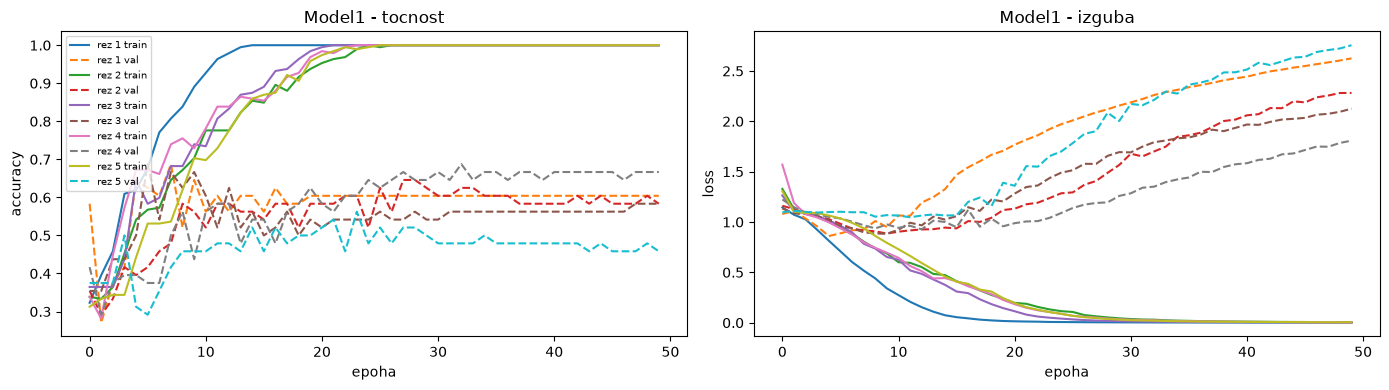

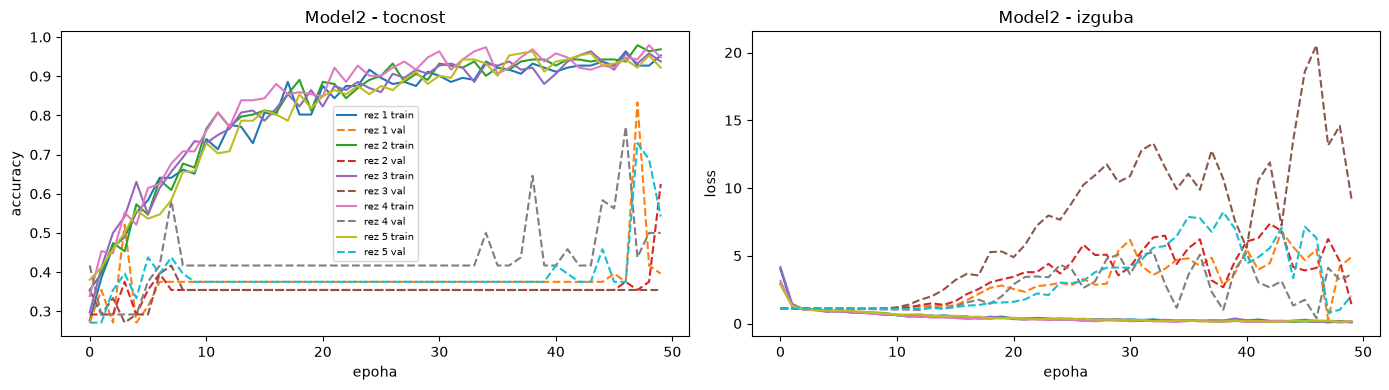

In [7]:
# Graf zgodovine ucenja - vse krivulje (tocnost in izguba) za oba modela
for ime in ['Model1','Model2']:
    fig, ax = plt.subplots(1, 2, figsize=(14,4))
    for fold, h in enumerate(zgodovine[ime], 1):
        ax[0].plot(h['accuracy'], label=f'rez {fold} train')
        ax[0].plot(h['val_accuracy'], '--', label=f'rez {fold} val')
        ax[1].plot(h['loss'], label=f'rez {fold} train')
        ax[1].plot(h['val_loss'], '--', label=f'rez {fold} val')
    ax[0].set_title(f'{ime} - tocnost'); ax[0].set_xlabel('epoha'); ax[0].set_ylabel('accuracy')
    ax[1].set_title(f'{ime} - izguba'); ax[1].set_xlabel('epoha'); ax[1].set_ylabel('loss')
    ax[0].legend(fontsize=7); plt.tight_layout(); plt.show()

## Primerjava napovednih modelov

Povprecne vrednosti metrik, grafikoni kvartilov (boxplot) in stolpicni diagrami.

In [8]:
# Povprecne vrednosti posamezne metrike za vsak model
METRIKE = ['accuracy','f1','precision','recall']
povprecja = {}
for ime in ['Model1','Model2']:
    dfm = pd.DataFrame(rezultati[ime])
    povprecja[ime] = dfm.mean()
povp_df = pd.DataFrame(povprecja).T
print('Povprecne metrike po precnih rezih:')
povp_df

Povprecne metrike po precnih rezih:


,accuracy,f1,precision,recall
Model1,0.520000,0.519207,0.52894,0.520000
Model2,0.633333,0.600692,0.82472,0.633333


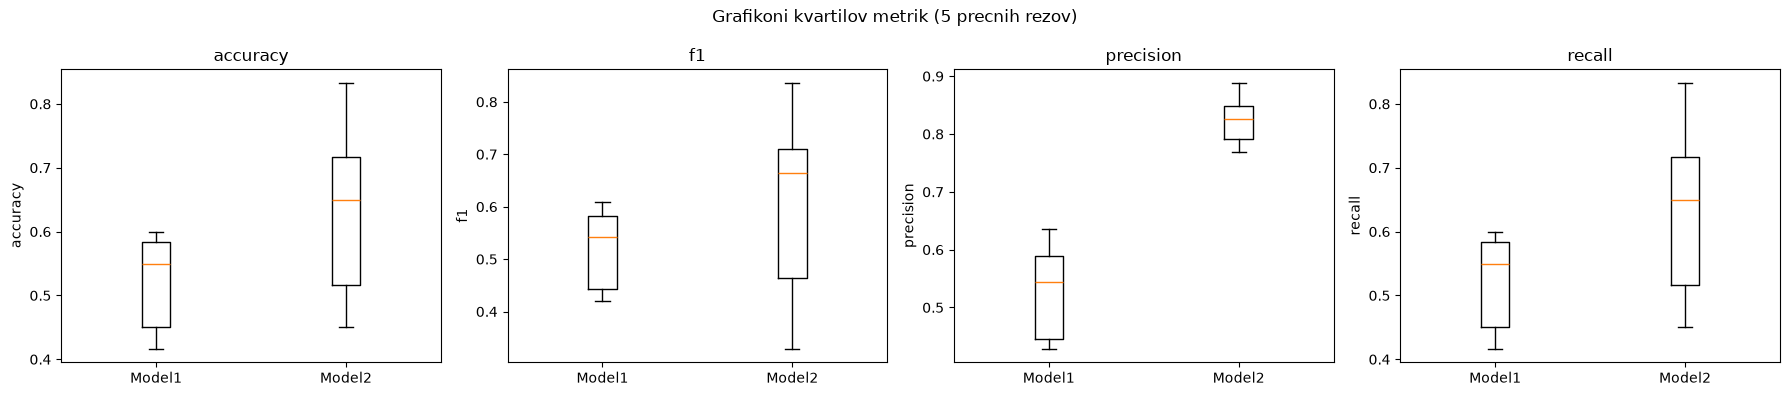

In [9]:
# Grafikoni kvartilov (boxplot) - en boxplot na metriko (skupno 4)
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, metr in zip(axes, METRIKE):
    podatki = [[r[metr] for r in rezultati[ime]] for ime in ['Model1','Model2']]
    ax.boxplot(podatki, tick_labels=['Model1','Model2'])
    ax.set_title(metr); ax.set_ylabel(metr)
plt.suptitle('Grafikoni kvartilov metrik (5 precnih rezov)')
plt.tight_layout(); plt.show()

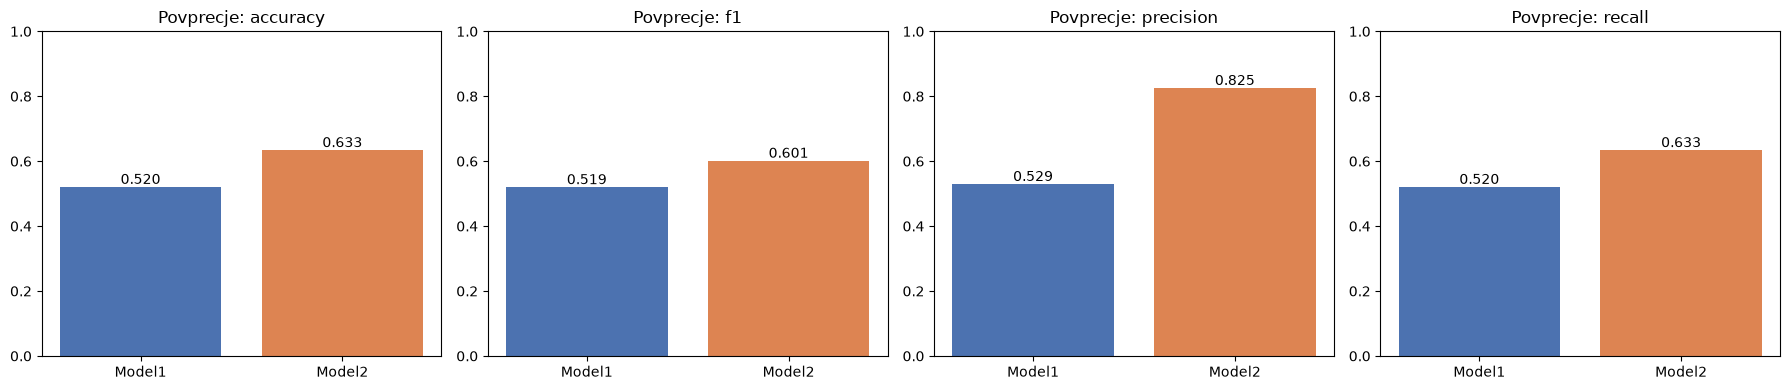

Opomba: CNN modeli dosegajo bistveno vecjo tocnost kot klasicni algoritmi strojnega ucenja (naloge 3/4), saj samodejno ucijo prostorske znacilnice iz slik.


In [10]:
# Stolpicni diagrami povprecnih vrednosti vsake metrike
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, metr in zip(axes, METRIKE):
    vals = [povprecja[ime][metr] for ime in ['Model1','Model2']]
    ax.bar(['Model1','Model2'], vals, color=['#4C72B0','#DD8452'])
    ax.set_title(f'Povprecje: {metr}'); ax.set_ylim(0,1)
    for i,v in enumerate(vals): ax.text(i, v+0.01, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()
print('Opomba: CNN modeli dosegajo bistveno vecjo tocnost kot klasicni algoritmi strojnega '
      'ucenja (naloge 3/4), saj samodejno ucijo prostorske znacilnice iz slik.')

## Dodatni del - shranjevanje najboljsega modela

Najboljsi model (najvecja povprecna tocnost) ponovno naucimo na vseh podatkih in shranimo
za uporabo v spletni storitvi (naloga 7, koncna tocka `/predict/naloga5`).

In [11]:
# Izbira najboljse arhitekture in ponovno ucenje na celotni zbirki
najboljsi = max(['Model1','Model2'], key=lambda k: povprecja[k]['accuracy'])
print('Najboljsi model:', najboljsi, 'povp. tocnost', round(povprecja[najboljsi]['accuracy'],3))

full_train = train_datagen_aug.flow_from_dataframe(
    df, x_col='filepath', y_col='label', target_size=IMG_SIZE, color_mode='grayscale',
    class_mode='categorical', classes=RAZREDI, batch_size=16, subset='training', shuffle=True, seed=1234)
full_val = train_datagen_aug.flow_from_dataframe(
    df, x_col='filepath', y_col='label', target_size=IMG_SIZE, color_mode='grayscale',
    class_mode='categorical', classes=RAZREDI, batch_size=16, subset='validation', shuffle=True, seed=1234)

final_model = build_model2() if najboljsi=='Model2' else build_model1()
final_model.fit(full_train, validation_data=full_val, epochs=EPOCHS, verbose=0)
final_model.save('model_naloga5.keras')
with open('razredi_naloga5.pkl','wb') as f:
    pickle.dump(RAZREDI, f)
print('Shranjeno: model_naloga5.keras, razredi_naloga5.pkl')

Najboljsi model: Model2 povp. tocnost 0.633
Found 240 validated image filenames belonging to 3 classes.


Found 60 validated image filenames belonging to 3 classes.


Shranjeno: model_naloga5.keras, razredi_naloga5.pkl
